#### Maxwell Hasenauer
#### NUID:

## Exercise 4

#### question 3: Blackjack

a) Implement a first-visit Monte-Carlo policy evaluation (prediction).
Apply it to the Blackjack environment for the "sticks only on 20 or 21" policy to reproduce figure 5.1.


In [75]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install "gym<=0.21.0"

You should consider upgrading via the 'C:\Users\max\Anaconda3\python.exe -m pip install --upgrade pip' command.


In [101]:
#import gymnasium as gym
import gym
import numpy as np
import matplotlib as plt
from typing import Callable, Tuple
from collections import defaultdict
from tqdm import trange

env = gym.make("Blackjack-v0")

In [102]:
env.reset()

(20, 7, False)

In [103]:
env.action_space

Discrete(2)

In [104]:
env.observation_space

Tuple(Discrete(32), Discrete(11), Discrete(2))

In [105]:
env.dealer

[7, 7]

In [106]:
env.player

[10, 10]

In [107]:
env.step(1)

((21, 7, False), 0, False, {})

In [108]:
env.step(1)

((30, 7, False), -1, True, {})

In [109]:
env.step(1)

((32, 7, False), -1, True, {})

In [110]:
env.step(1)

((37, 7, False), -1, True, {})

## First-Visit MC Prediction

**Input:** a policy pi to be evaluated  

**Initialize:**  
    &emsp;&ensp;&ensp;V (s) elm R, arbitrarily, for all s elm S  
    &emsp;&ensp;&ensp;Returns(s) = an empty list, for all s elm S  
**Loop forever** (for each episode):  
    &emsp;&ensp;&ensp;Generate an episode following pi: S0, A0, R1, S1, A1, R2,...,ST 1, AT-1, RT 
    &emsp;&ensp;&ensp;G = 0  
    &emsp;&ensp;&ensp;**Loop for each step of episode**, t = T-1, T-2,..., 0:  
        &emsp;&emsp;&emsp;G = gamma*G + R_t+1  
        &emsp;&emsp;&emsp;Unless St appears in S0, S1,...,S_t-1:  
        &emsp;&emsp;&emsp;&emsp;Append G to Returns(St)  
        &emsp;&emsp;&emsp;&emsp;V (St) = average(Returns(St)) 

In [111]:
def default_blackjack_policy(state: Tuple[int, int, bool]) -> int:
    """default_blackjack_policy.

    Returns sticking on 20 or 21 and hit otherwise

    Args:
        state: the current state
    """
    if state[0] in [20, 21]:
        return 0
    else:
        return 1
    
def generate_episode(env: gym.Env, policy: Callable, es: bool = False):
    """A function to generate one episode and collect the sequence of (s, a, r) tuples

    This function will be useful for implementing the MC methods

    Args:
        env (gym.Env): a Gym API compatible environment
        policy (Callable): A function that represents the policy.
        es (bool): Whether to use exploring starts or not
    """
    episode = []
    state = env.reset()
    #print(f"state: {state}")
    while True:
        if es and len(episode) == 0:
            action = env.action_space.sample()
        else:
            action = policy(state)
            #print(f"action: {action}")
        next_state, reward, done, _ = env.step(action)
        #print(f"next state: {next_state}, reward: {reward}, done: {done}")
        episode.append((state, action, reward))
        #print(f"episode: {episode}")
        if done:
            break
        state = next_state
    
    return episode

def on_policy_mc_evaluation(
    env: gym.Env,
    policy: Callable,
    num_episodes: int,
    gamma: float,
) -> defaultdict:
    """On-policy Monte Carlo policy evaluation. First visits will be used.

    Args:
        env (gym.Env): a Gym API compatible environment
        policy (Callable): A function that represents the policy.
        num_episodes (int): Number of episodes
        gamma (float): Discount factor of MDP

    Returns:
        V (defaultdict): The values for each state. V[state] = value.
    """
    # We use defaultdicts here for both V and N for convenience. The states will be the keys.
    V = defaultdict(float)
    N = defaultdict(int)

    for _ in trange(num_episodes, desc="Episode"):
        #print("__________NEW EPISODE___________")
        episode = generate_episode(env, policy)
        #print(episode)
        G = 0
        for t in range(len(episode) - 1, -1, -1):
            # TODO Q3a
            # Update V and N here according to first visit MC
            #print(f"t: {t}")
            #print(f"G: {G}")
            G = gamma*G + episode[t][2]
            N[episode[t][0]]+=1
            first_visit = True
            for t_ in range(t):
                if episode[t][0] == episode[t_][0]:
                    first_visit = False
            if first_visit:
                V[episode[t][0]] = V[episode[t][0]] + (G - V[episode[t][0]]) / N[episode[t][0]]
    return V

In [185]:
E = generate_episode(env, default_blackjack_policy)



In [126]:
V_keys = list(V.keys())
V_keys.sort()
V_states= {i:V[i] for i in V_keys}
V_states

{(4, 1, False): -0.38475000000000004,
 (4, 2, False): -0.7940250000000001,
 (4, 3, False): 0.2400000000000001,
 (4, 4, False): -0.8254285714285714,
 (4, 5, False): -0.87,
 (4, 6, False): -0.32130000000000003,
 (4, 7, False): -0.8145,
 (4, 8, False): 0.002024999999999999,
 (4, 9, False): -0.41625,
 (4, 10, False): -0.6271363636363637,
 (5, 1, False): -0.7488000000000001,
 (5, 2, False): -0.504,
 (5, 3, False): -0.35200000000000004,
 (5, 4, False): -0.5048935714285715,
 (5, 5, False): -0.8357142857142857,
 (5, 6, False): -0.5835857142857144,
 (5, 7, False): -0.40725,
 (5, 8, False): -0.4087058823529412,
 (5, 9, False): -0.6147,
 (5, 10, False): -0.4510092857142857,
 (6, 1, False): -0.29913545454545454,
 (6, 2, False): -0.6880909090909093,
 (6, 3, False): -0.36540000000000006,
 (6, 4, False): -0.17999999999999997,
 (6, 5, False): -0.11710000000000002,
 (6, 6, False): -0.6057075000000001,
 (6, 7, False): -0.5275384615384615,
 (6, 8, False): -0.37905,
 (6, 9, False): -0.2061,
 (6, 10, False

In [130]:
np.random.choice([0,1])

0

In [131]:
E[0][:2]

((19, 10, True), 1)

In [132]:
env.action_space.n
Q = defaultdict(lambda: np.zeros(env.action_space.n))
N = defaultdict(lambda: np.zeros(env.action_space.n))
np.zeros(env.action_space.n)

array([0., 0.])

In [133]:
from policy import create_blackjack_policy

def on_policy_mc_control_es(
    env: gym.Env, num_episodes: int, gamma: float
) -> Tuple[defaultdict, Callable]:
    """On-policy Monte Carlo control with exploring starts for Blackjack

    Args:
        env (gym.Env): a Gym API compatible environment
        num_episodes (int): Number of episodes
        gamma (float): Discount factor of MDP
    """
    # We use defaultdicts here for both Q and N for convenience. The states will be the keys and the values will be numpy arrays with length = num actions
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    N = defaultdict(lambda: np.zeros(env.action_space.n))

    # If the state was seen, use the greedy action using Q values.
    # Else, default to the original policy of sticking to 20 or 21.
    policy = create_blackjack_policy(Q)

    for _ in trange(num_episodes, desc="Episode"):
        # TODO Q3b
        # Note there is no need to update the policy here directly.
        # By updating Q, the policy will automatically be updated.
        
        episode = generate_episode(env, policy, es=True)
        G = 0
        for t in range(len(episode) - 1, -1, -1):
            G = gamma*G + episode[t][2]
            N[episode[t][0]][episode[t][1]]+=1
            first_visit = True
            for t_ in range(t):
                if episode[t][:2] == episode[t_][:2]:
                    first_visit = False
            if first_visit:
                Old_Q = Q[episode[t][0]][episode[t][1]]
                Q[episode[t][0]][episode[t][1]] = Old_Q + (G - Old_Q) / (N[episode[t][0]][episode[t][1]])
                
    return Q, policy


In [308]:
Q,policy_es = on_policy_mc_control_es(env,10000,0.9)
Q_500,policy_500 = on_policy_mc_control_es(env,500000,0.9)



Episode:   0%|                                                                               | 0/10000 [00:00<?, ?it/s]

Episode:  11%|███████                                                          | 1088/10000 [00:00<00:00, 10801.08it/s]

Episode:  22%|██████████████▏                                                  | 2184/10000 [00:00<00:00, 10823.66it/s]

Episode:  34%|██████████████████████                                           | 3391/10000 [00:00<00:00, 11147.16it/s]

Episode:  46%|█████████████████████████████▋                                   | 4568/10000 [00:00<00:00, 11303.37it/s]

Episode:  58%|█████████████████████████████████████▌                           | 5788/10000 [00:00<00:00, 11545.93it/s]

Episode:  70%|█████████████████████████████████████████████▌                   | 7007/10000 [00:00<00:00, 11728.32it/s]

Episode:  81%|████████████████████████████████████████████████████▎            | 8056/10000 [00:00<00:00, 11145.01it/s]

Episode: 100%|████████████████

Episode:  13%|████████▏                                                      | 65243/500000 [00:05<00:39, 10938.87it/s]

Episode:  13%|████████▎                                                      | 66339/500000 [00:06<00:40, 10635.80it/s]

Episode:  14%|████████▌                                                      | 67500/500000 [00:06<00:39, 10888.13it/s]

Episode:  14%|████████▋                                                      | 68593/500000 [00:06<00:40, 10623.82it/s]

Episode:  14%|████████▊                                                      | 69773/500000 [00:06<00:39, 10930.03it/s]

Episode:  14%|████████▉                                                      | 70939/500000 [00:06<00:38, 11114.82it/s]

Episode:  14%|█████████                                                      | 72076/500000 [00:06<00:38, 11182.40it/s]

Episode:  15%|█████████▏                                                     | 73198/500000 [00:06<00:39, 10830.92it/s]

Episode:  15%|█████████▌        

Episode:  28%|█████████████████▏                                            | 138820/500000 [00:13<00:31, 11336.23it/s]

Episode:  28%|█████████████████▎                                            | 140005/500000 [00:13<00:31, 11462.44it/s]

Episode:  28%|█████████████████▌                                            | 141223/500000 [00:13<00:30, 11642.35it/s]

Episode:  28%|█████████████████▋                                            | 142407/500000 [00:13<00:30, 11677.46it/s]

Episode:  29%|█████████████████▊                                            | 143577/500000 [00:13<00:31, 11366.90it/s]

Episode:  29%|█████████████████▉                                            | 144770/500000 [00:13<00:30, 11516.24it/s]

Episode:  29%|██████████████████                                            | 145925/500000 [00:13<00:31, 11069.40it/s]

Episode:  29%|██████████████████▏                                           | 147038/500000 [00:13<00:31, 11066.36it/s]

Episode:  30%|██████████████████

Episode:  43%|██████████████████████████▌                                   | 214521/500000 [00:20<00:27, 10453.37it/s]

Episode:  43%|██████████████████████████▋                                   | 215637/500000 [00:20<00:26, 10655.15it/s]

Episode:  43%|██████████████████████████▉                                   | 216777/500000 [00:20<00:26, 10860.16it/s]

Episode:  44%|███████████████████████████                                   | 217874/500000 [00:20<00:26, 10772.93it/s]

Episode:  44%|███████████████████████████▏                                  | 218984/500000 [00:20<00:25, 10844.84it/s]

Episode:  44%|███████████████████████████▎                                  | 220105/500000 [00:20<00:25, 10942.06it/s]

Episode:  44%|███████████████████████████▍                                  | 221240/500000 [00:20<00:25, 11028.63it/s]

Episode:  44%|███████████████████████████▌                                  | 222398/500000 [00:20<00:24, 11164.74it/s]

Episode:  45%|██████████████████

Episode:  58%|████████████████████████████████████▏                         | 291807/500000 [00:26<00:18, 11034.28it/s]

Episode:  59%|████████████████████████████████████▎                         | 292914/500000 [00:27<00:18, 10988.08it/s]

Episode:  59%|████████████████████████████████████▍                         | 294034/500000 [00:27<00:18, 11027.07it/s]

Episode:  59%|████████████████████████████████████▌                         | 295139/500000 [00:27<00:19, 10753.37it/s]

Episode:  59%|████████████████████████████████████▋                         | 296217/500000 [00:27<00:19, 10518.39it/s]

Episode:  59%|████████████████████████████████████▉                         | 297422/500000 [00:27<00:18, 10913.71it/s]

Episode:  60%|█████████████████████████████████████                         | 298520/500000 [00:27<00:18, 10655.10it/s]

Episode:  60%|█████████████████████████████████████▏                        | 299660/500000 [00:27<00:18, 10857.00it/s]

Episode:  60%|██████████████████

Episode:  74%|█████████████████████████████████████████████▊                | 369644/500000 [00:33<00:11, 11437.28it/s]

Episode:  74%|█████████████████████████████████████████████▉                | 370800/500000 [00:34<00:11, 11447.57it/s]

Episode:  74%|██████████████████████████████████████████████▏               | 372036/500000 [00:34<00:10, 11682.79it/s]

Episode:  75%|██████████████████████████████████████████████▎               | 373255/500000 [00:34<00:10, 11822.88it/s]

Episode:  75%|██████████████████████████████████████████████▍               | 374440/500000 [00:34<00:10, 11699.34it/s]

Episode:  75%|██████████████████████████████████████████████▌               | 375612/500000 [00:34<00:11, 11252.51it/s]

Episode:  75%|██████████████████████████████████████████████▋               | 376815/500000 [00:34<00:10, 11452.24it/s]

Episode:  76%|██████████████████████████████████████████████▊               | 377965/500000 [00:34<00:10, 11333.79it/s]

Episode:  76%|██████████████████

Episode:  88%|███████████████████████████████████████████████████████▋       | 441626/500000 [00:43<00:26, 2213.58it/s]

Episode:  88%|███████████████████████████████████████████████████████▋       | 442397/500000 [00:43<00:20, 2813.13it/s]

Episode:  89%|███████████████████████████████████████████████████████▊       | 443247/500000 [00:43<00:16, 3516.36it/s]

Episode:  89%|███████████████████████████████████████████████████████▉       | 443838/500000 [00:43<00:22, 2471.39it/s]

Episode:  89%|████████████████████████████████████████████████████████       | 444696/500000 [00:44<00:17, 3140.42it/s]

Episode:  89%|████████████████████████████████████████████████████████       | 445272/500000 [00:44<00:19, 2753.80it/s]

Episode:  89%|████████████████████████████████████████████████████████▏      | 445740/500000 [00:44<00:27, 1996.12it/s]

Episode:  89%|████████████████████████████████████████████████████████▏      | 446104/500000 [00:44<00:23, 2284.10it/s]

Episode:  89%|██████████████████

In [312]:
Q_SA = list(Q.keys())
Q_SA.sort()
state_action_Q = {i:Q[i] for i in Q_SA}
state_action_Q

{(4, 1, False): array([0.  , 0.81]),
 (4, 2, False): array([-0.5 , -0.81]),
 (4, 3, False): array([-0.6 , -0.81]),
 (4, 4, False): array([ 0. , -0.9]),
 (4, 5, False): array([-0.33333333,  0.27      ]),
 (4, 6, False): array([-0.33333333, -0.735     ]),
 (4, 7, False): array([-1.,  0.]),
 (4, 8, False): array([-0.33333333, -0.87      ]),
 (4, 9, False): array([ 0.    , -0.4275]),
 (4, 10, False): array([-0.71428571, -0.23271429]),
 (5, 1, False): array([-0.33333333, -0.89      ]),
 (5, 2, False): array([-0.6  , -0.273]),
 (5, 3, False): array([-0.2       , -0.36128571]),
 (5, 4, False): array([ 0.    , -0.1818]),
 (5, 5, False): array([-0.14285714, -0.045     ]),
 (5, 6, False): array([0., 0.]),
 (5, 7, False): array([-0.66666667,  0.162     ]),
 (5, 8, False): array([-1.      , -0.653625]),
 (5, 9, False): array([-1.   , -0.342]),
 (5, 10, False): array([-0.81818182, -0.26720526]),
 (6, 1, False): array([-1.        , -0.51128182]),
 (6, 2, False): array([-0.66666667,  0.18      ]),
 (

In [313]:
#print(max_x,min_x,max_y,min_y)
#ace_grid = np.meshgrid(np.linspace(min_x,max_x,(max_x-min_x+1)),np.linspace(min_y,max_y,(max_y-min_y+1)))

In [314]:
"""
#xx,yy=np.meshgrid(x,y[::-1])
z=np.zeros(ace_grid[0].shape)
#print(x,y[::-1])
for i in range(len(x)):
    for j in range(len(y)):
        print(f"i,j: {i,j}")
        #print(f"tuple:{tuple([x[i],y[j]])}")
        t_=tuple([x[i],y[j]])
        print(f"t_: {t_}")
        print(f"ace at tuple: {ace[t_]}")
        #z[i][j]=ace[(x[i],y[j])]`"""
V[12:22,1:,0]


TypeError: unhashable type: 'slice'

In [315]:
V = on_policy_mc_evaluation(env, default_blackjack_policy,10000,0.9)
V_500 = on_policy_mc_evaluation(env, default_blackjack_policy,500000,0.9)



Episode:   0%|                                                                               | 0/10000 [00:00<?, ?it/s]

Episode:  11%|███████▎                                                         | 1130/10000 [00:00<00:00, 11218.09it/s]

Episode:  23%|██████████████▉                                                  | 2307/10000 [00:00<00:00, 11352.50it/s]

Episode:  35%|██████████████████████▊                                          | 3518/10000 [00:00<00:00, 11545.96it/s]

Episode:  47%|██████████████████████████████▋                                  | 4714/10000 [00:00<00:00, 11649.88it/s]

Episode:  57%|█████████████████████████████████████▎                           | 5749/10000 [00:00<00:00, 11225.34it/s]

Episode:  69%|████████████████████████████████████████████▌                    | 6862/10000 [00:00<00:00, 11170.87it/s]

Episode:  81%|████████████████████████████████████████████████████▎            | 8052/10000 [00:00<00:00, 11369.71it/s]

Episode: 100%|████████████████

Episode:  13%|████████▎                                                      | 65954/500000 [00:06<00:38, 11163.70it/s]

Episode:  13%|████████▍                                                      | 67083/500000 [00:06<00:40, 10581.53it/s]

Episode:  14%|████████▌                                                      | 68156/500000 [00:06<00:42, 10239.36it/s]

Episode:  14%|████████▊                                                       | 69193/500000 [00:06<00:44, 9574.45it/s]

Episode:  14%|████████▊                                                      | 70324/500000 [00:06<00:42, 10031.41it/s]

Episode:  14%|█████████                                                      | 71470/500000 [00:06<00:41, 10414.30it/s]

Episode:  15%|█████████▏                                                     | 72657/500000 [00:07<00:39, 10790.38it/s]

Episode:  15%|█████████▎                                                     | 73779/500000 [00:07<00:39, 10913.41it/s]

Episode:  15%|█████████▍        

Episode:  28%|█████████████████                                             | 137890/500000 [00:14<00:30, 11920.80it/s]

Episode:  28%|█████████████████▏                                            | 139091/500000 [00:14<00:30, 11921.43it/s]

Episode:  28%|█████████████████▍                                            | 140285/500000 [00:14<00:30, 11760.57it/s]

Episode:  28%|█████████████████▌                                            | 141463/500000 [00:14<00:30, 11671.10it/s]

Episode:  29%|█████████████████▋                                            | 142718/500000 [00:14<00:30, 11895.12it/s]

Episode:  29%|█████████████████▊                                            | 143945/500000 [00:15<00:29, 11979.39it/s]

Episode:  29%|█████████████████▉                                            | 145145/500000 [00:15<00:30, 11817.31it/s]

Episode:  29%|██████████████████▏                                           | 146329/500000 [00:15<00:30, 11640.48it/s]

Episode:  29%|██████████████████

Episode:  43%|██████████████████████████▋                                   | 215718/500000 [00:21<00:25, 11104.60it/s]

Episode:  43%|██████████████████████████▉                                   | 216833/500000 [00:21<00:25, 10931.21it/s]

Episode:  44%|███████████████████████████                                   | 218032/500000 [00:21<00:25, 11215.27it/s]

Episode:  44%|███████████████████████████▏                                  | 219160/500000 [00:21<00:25, 11210.18it/s]

Episode:  44%|███████████████████████████▎                                  | 220350/500000 [00:21<00:24, 11384.64it/s]

Episode:  44%|███████████████████████████▍                                  | 221492/500000 [00:21<00:25, 11041.51it/s]

Episode:  45%|███████████████████████████▌                                  | 222601/500000 [00:22<00:25, 10693.16it/s]

Episode:  45%|███████████████████████████▋                                  | 223709/500000 [00:22<00:25, 10791.84it/s]

Episode:  45%|██████████████████

Episode:  59%|████████████████████████████████████▍                         | 293461/500000 [00:28<00:18, 11210.20it/s]

Episode:  59%|████████████████████████████████████▌                         | 294586/500000 [00:28<00:18, 10916.54it/s]

Episode:  59%|████████████████████████████████████▋                         | 295790/500000 [00:28<00:18, 11201.18it/s]

Episode:  59%|████████████████████████████████████▊                         | 296960/500000 [00:28<00:17, 11322.24it/s]

Episode:  60%|████████████████████████████████████▉                         | 298096/500000 [00:28<00:18, 10918.53it/s]

Episode:  60%|█████████████████████████████████████                         | 299289/500000 [00:28<00:17, 11180.38it/s]

Episode:  60%|█████████████████████████████████████▎                        | 300434/500000 [00:29<00:17, 11236.14it/s]

Episode:  60%|█████████████████████████████████████▍                        | 301562/500000 [00:29<00:17, 11060.86it/s]

Episode:  61%|██████████████████

Episode:  74%|██████████████████████████████████████████████                | 371883/500000 [00:35<00:10, 11709.26it/s]

Episode:  75%|██████████████████████████████████████████████▎               | 373056/500000 [00:35<00:11, 11484.20it/s]

Episode:  75%|██████████████████████████████████████████████▍               | 374207/500000 [00:35<00:11, 11431.64it/s]

Episode:  75%|██████████████████████████████████████████████▌               | 375431/500000 [00:35<00:10, 11644.08it/s]

Episode:  75%|██████████████████████████████████████████████▋               | 376598/500000 [00:35<00:10, 11515.78it/s]

Episode:  76%|██████████████████████████████████████████████▊               | 377757/500000 [00:35<00:10, 11514.58it/s]

Episode:  76%|██████████████████████████████████████████████▉               | 378910/500000 [00:35<00:10, 11122.06it/s]

Episode:  76%|███████████████████████████████████████████████               | 380026/500000 [00:36<00:11, 10834.64it/s]

Episode:  76%|██████████████████

Episode:  89%|████████████████████████████████████████████████████████       | 444510/500000 [00:42<00:05, 9889.19it/s]

Episode:  89%|███████████████████████████████████████████████████████▎      | 445608/500000 [00:42<00:05, 10172.29it/s]

Episode:  89%|███████████████████████████████████████████████████████▍      | 446631/500000 [00:42<00:05, 10107.18it/s]

Episode:  90%|████████████████████████████████████████████████████████▍      | 447646/500000 [00:42<00:05, 9835.47it/s]

Episode:  90%|███████████████████████████████████████████████████████▋      | 448748/500000 [00:42<00:05, 10142.70it/s]

Episode:  90%|███████████████████████████████████████████████████████▊      | 449855/500000 [00:43<00:04, 10382.70it/s]

Episode:  90%|███████████████████████████████████████████████████████▉      | 450943/500000 [00:43<00:04, 10503.58it/s]

Episode:  90%|████████████████████████████████████████████████████████      | 452058/500000 [00:43<00:04, 10667.36it/s]

Episode:  91%|██████████████████

In [317]:
ace_10 = defaultdict(float)
no_ace_10 = defaultdict(float)
ace_500 = defaultdict(float)
no_ace_500 = defaultdict(float)

for v in V:
    if v[2] == 0:
        no_ace_10[v[0:2]] = V[v]
    else:
        ace_10[v[0:2]] = V[v]
        
for v in V_500:
    if v[2] == 0:
        no_ace_500[v[0:2]] = V_500[v]
    else:
        ace_500[v[0:2]] = V_500[v]
        
x_a_10=[]
y_a_10=[]
x_na_10=[]
y_na_10=[]

x_a_500=[]
y_a_500=[]
x_na_500=[]
y_na_500=[]

for v in ace_10:
    if v[1] not in x_a_10:
        x_a_10.append(v[1])
    if v[0] not in y_a_10:
        y_a_10.append(v[0])
        
for v in no_ace_10:
    if v[1] not in x_na_10:
        x_na_10.append(v[1])
    if v[0] not in y_na_10:
        y_na_10.append(v[0])
        
for v in ace_500:
    if v[1] not in x_a_500:
        x_a_500.append(v[1])
    if v[0] not in y_a_500:
        y_a_500.append(v[0])
        
for v in no_ace_500:
    if v[1] not in x_na_500:
        x_na_500.append(v[1])
    if v[0] not in y_na_500:
        y_na_500.append(v[0])

x_a_10=sorted(x_a_10)
y_a_10=sorted(y_a_10)
x_na_10=sorted(x_na_10)
y_na_10=sorted(y_na_10)
        
x_a_500=sorted(x_a_500)
y_a_500=sorted(y_a_500)
x_na_500=sorted(x_na_500)
y_na_500=sorted(y_na_500)

print(x_a_10,x_na_10,x_a_500,x_na_500)
print(y_a_10,y_na_10,y_a_500,y_na_500)

im_10_a=np.zeros((len(x_a_10),len(y_a_10)))
im_10_na=np.zeros((len(x_na_10),len(y_na_10)))
im_500_a=np.zeros((len(x_a_500),len(y_a_500)))
im_500_na=np.zeros((len(x_na_500),len(y_na_500)))

def create_image(im,x,y,a_na):
    x_min, x_max, y_min, y_max = min(x), max(x), min(y), max(y)
    for a in a_na:
        im[a[1]-x_min][a[0]-y_min]=a_na[a]
    return im

im_10_a = create_image(im_10_a,x_a_10,y_a_10,ace_10)
im_10_na = create_image(im_10_na,x_na_10,y_na_10,no_ace_10)
im_500_a = create_image(im_500_a,x_a_500,y_a_500,ace_500)
im_500_na = create_image(im_500_na,x_na_500,y_na_500,no_ace_500)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[12, 13, 14, 15, 16, 17, 18, 19, 20, 21] [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21] [12, 13, 14, 15, 16, 17, 18, 19, 20, 21] [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


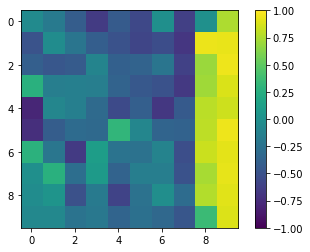

In [318]:
#10,000 episodes usable ace on-policy eval
import matplotlib.pyplot as plt
plt.imshow(im_10_a, vmin = -1, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
plt.show()

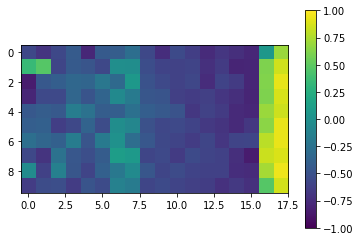

In [319]:
#10,000 episodes no usable ace on-policy eval
#no usable ace, x-axis has a wider range
import matplotlib.pyplot as plt
plt.imshow(im_10_na, vmin = -1, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
plt.show()

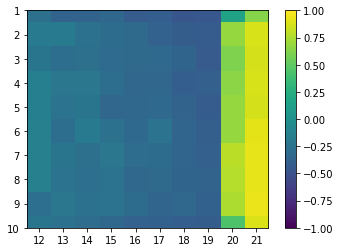

In [320]:
#500,000 episodes usable ace on-policy eval
import matplotlib.pyplot as plt
plt.imshow(im_500_a, vmin = -1, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
default_y_ticks = range(len(x_a_500))
default_x_ticks = range(len(y_a_500))
plt.xticks(default_x_ticks,y_a_500)
plt.yticks(default_y_ticks,x_a_500)
plt.show()

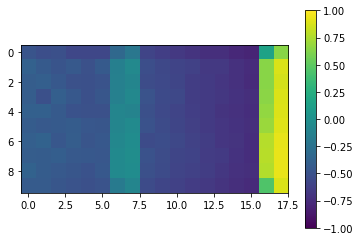

In [321]:
#500,000 episodes no usable ace on-policy eval
#no usable ace, x-axis has a wider range
import matplotlib.pyplot as plt
plt.imshow(im_500_na, vmin = -1, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
plt.show()

In [322]:
q=[1,2,3,4,56,3,2,2,3,4,5]
q.index(max(q))

4

In [327]:
qace_10 = defaultdict(float)
no_qace_10 = defaultdict(float)
qace_500 = defaultdict(float)
no_qace_500 = defaultdict(float)
q_policy_a = defaultdict(int)
q_policy_na = defaultdict(int)

for v in Q:
    if q[2] == 0:
        no_qace_10[v[0:2]] = max(Q[v])
    else:
        qace_10[v[0:2]] = max(Q[v])
        
        
for v in Q_500:
    if v[2] == 0:
        no_qace_500[v[0:2]] = max(Q_500[v])
        q_policy_a[v[:2]] = np.where(Q_500[v] == max(Q_500[v]))[0]
    else:
        qace_500[v[0:2]] = max(Q_500[v])
        q_policy_na[v[:2]] = np.where(Q_500[v] == max(Q_500[v]))[0]
        
        
x_qa_10=[]
y_qa_10=[]
x_qna_10=[]
y_qna_10=[]

x_qa_500=[]
y_qa_500=[]
x_qna_500=[]
y_qna_500=[]

for v in qace_10:
    if v[1] not in x_qa_10:
        x_qa_10.append(v[1])
    if v[0] not in y_qa_10:
        y_qa_10.append(v[0])
        
for v in no_qace_10:
    if v[1] not in x_qna_10:
        x_qna_10.append(v[1])
    if v[0] not in y_qna_10:
        y_qna_10.append(v[0])
        
for v in qace_500:
    if v[1] not in x_qa_500:
        x_qa_500.append(v[1])
    if v[0] not in y_qa_500:
        y_qa_500.append(v[0])
        
for v in no_qace_500:
    if v[1] not in x_qna_500:
        x_qna_500.append(v[1])
    if v[0] not in y_qna_500:
        y_qna_500.append(v[0])

x_qa_10=sorted(x_qa_10)
y_qa_10=sorted(y_qa_10)
x_qna_10=sorted(x_qna_10)
y_qna_10=sorted(y_qna_10)
        
x_qa_500=sorted(x_qa_500)
y_qa_500=sorted(y_qa_500)
x_qna_500=sorted(x_qna_500)
y_qna_500=sorted(y_qna_500)

print(x_qa_10,x_qna_10,x_qa_500,x_qna_500)
print(y_qa_10,y_qna_10,y_qa_500,y_qna_500)

im_10_qa=np.zeros((len(x_qa_500),len(y_qa_500)))
im_10_qna=np.zeros((len(x_qna_10),len(y_qna_10)))
im_500_qa=np.zeros((len(x_qa_500),len(y_qa_500)))
im_500_qna=np.zeros((len(x_qna_500),len(y_qna_500)))

im_policy_a=np.zeros((len(x_qa_500),len(y_qa_500)))
im_policy_na=np.zeros((len(x_qna_500),len(y_qna_500)))

im_10_qa = create_image(im_10_qa,x_qa_500,y_qa_500,qace_10)
im_10_qna = create_image(im_10_qna,x_qa_10,y_qa_10,no_qace_10)
im_500_qa = create_image(im_500_qa,x_qa_500,y_qa_500,qace_500)
im_500_qna = create_image(im_500_qna,x_qna_500,y_qna_500,no_qace_500)

im_policy_a = create_image(im_policy_a,x_qa_500,y_qa_500,qace_500)
im_policy_na = create_image(im_policy_na,x_qna_500,y_qna_500,no_qace_500)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [] [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21] [] [12, 13, 14, 15, 16, 17, 18, 19, 20, 21] [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


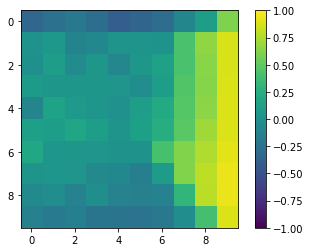

In [330]:
#500,000 episodes usable ace on-policy es
import matplotlib.pyplot as plt
plt.imshow(im_500_qa, vmin = -1, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
default_y_ticks = range(len(x_qa_500))
plt.show()

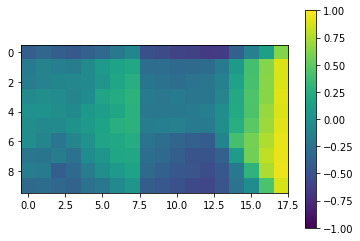

In [331]:
#500,000 episodes no usable ace on-policy es
#no usable ace, x-axis has a wider range
import matplotlib.pyplot as plt
plt.imshow(im_500_qna, vmin = -1, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
plt.show()

In [270]:
#for v in Q_500:
#    print(np.where(Q_500[v] == max(Q_500[v]))[0])
im_policy_a

array([[-0.25952597, -0.27333214, -0.29471889, -0.34961853, -0.31238532,
        -0.35341748, -0.30335928, -0.11111111,  0.17298578,  0.60999124],
       [ 0.032575  , -0.00240545,  0.06023462, -0.08390323, -0.02047253,
         0.09159292,  0.07715134,  0.37990196,  0.67256637,  0.8812825 ],
       [ 0.17193429,  0.06603317,  0.09387346, -0.10139781, -0.0094898 ,
         0.04090909,  0.19337017,  0.44556962,  0.59681093,  0.88716624],
       [ 0.01028864, -0.04719502,  0.00682529, -0.03156522, -0.00611263,
         0.07020528,  0.2025    ,  0.43734015,  0.65326633,  0.88362069],
       [ 0.15176796,  0.1543278 ,  0.08076106,  0.08247541,  0.14996217,
         0.09      ,  0.26086957,  0.45544554,  0.67381974,  0.88728814],
       [ 0.0743175 ,  0.13897649,  0.09540636,  0.14498182,  0.09952941,
         0.05781646,  0.25692695,  0.48291572,  0.65647059,  0.89298561],
       [ 0.09037105,  0.07302532,  0.07887439, -0.09371851,  0.11087463,
        -0.00271525,  0.49127182,  0.60136674

In [271]:

q_policy_a

defaultdict(int,
            {(17, 3): array([0], dtype=int64),
             (7, 3): array([1], dtype=int64),
             (14, 7): array([1], dtype=int64),
             (12, 7): array([1], dtype=int64),
             (13, 2): array([0], dtype=int64),
             (20, 10): array([0], dtype=int64),
             (17, 10): array([0], dtype=int64),
             (17, 1): array([0], dtype=int64),
             (21, 1): array([0], dtype=int64),
             (19, 1): array([0], dtype=int64),
             (9, 1): array([1], dtype=int64),
             (8, 4): array([1], dtype=int64),
             (20, 4): array([0], dtype=int64),
             (11, 6): array([1], dtype=int64),
             (11, 1): array([1], dtype=int64),
             (12, 10): array([1], dtype=int64),
             (20, 5): array([0], dtype=int64),
             (16, 5): array([0], dtype=int64),
             (12, 5): array([1], dtype=int64),
             (14, 10): array([1], dtype=int64),
             (13, 10): array([1], dtype=in

In [277]:
im_pol=np.zeros((len(x_qa_500),len(y_qa_500)))
for a in q_policy_a:
    im_pol[a[1]-min(x_qa_500)][a[0]-min(y_qa_500)]=q_policy_a[a]
im_pol

array([[1., 1., 1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 0., 0., 0., 1., 1., 0., 1., 1., 0.],
       [0., 0., 1., 1., 0., 1., 0., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 0., 1., 0.],
       [1., 0., 1., 1., 1., 1., 0., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.]])

In [279]:
im_pol_na=np.zeros((len(x_qna_500),len(y_qna_500)))
for a in q_policy_na:
    im_pol_na[a[1]-min(x_qna_500)][a[0]-min(y_qna_500)]=q_policy_na[a]
im_pol_na

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
        0., 0.]])

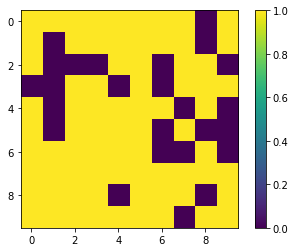

In [283]:
#500,000 policy maps ace
import matplotlib.pyplot as plt
plt.imshow(im_pol, vmin = 0, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
plt.show()

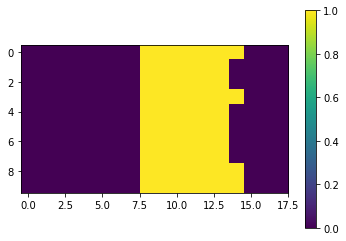

In [281]:
#500,000 policy maps no ace
import matplotlib.pyplot as plt
plt.imshow(im_pol_na, vmin = 0, vmax = 1)
plt.colorbar()
plt.axis(aspect='image')
plt.show()